#### Trabajo Práctico · 2.er Cuatrimestre 2026

### METODOS PREDICTIVOS PARA LA GESTION

#### Tecnicatura Universitaria en Gestión y Análisis de Datos - FCE UBA

--------------------------------------------------------------------------


### 0. DESCRIPCIÓN Y FUENTE DEL DATASET

Para el desarrollo del trabajo se seleccionó el dataset Online News Popularity, disponible en el UCI Machine Learning Repository.

La base contiene información sobre artículos publicados por Mashable durante un período de dos años. Cada registro representa un artículo y contiene distintas características asociadas a su contenido y publicación, como la cantidad de palabras del título y del artículo, número de imágenes y videos, cantidad de enlaces, palabras clave, temática, día de publicación y diferentes indicadores relacionados con la subjetividad y el sentimiento del contenido.

El dataset cuenta con 39.797 observaciones y 58 variables predictoras. Además, incluye variables no predictivas y la variable objetivo shares, que representa la cantidad de veces que cada artículo fue compartido en redes sociales.

El objetivo del análisis será estudiar la relación entre las características de los artículos y su popularidad, buscando predecir la cantidad de veces que un artículo será compartido. Debido a que la variable objetivo shares es numérica, el problema será abordado mediante técnicas de regresión.

Fuente: UCI Machine Learning Repository — Online News Popularity.
Autores: Kelwin Fernandes, Pedro Vinagre, Paulo Cortez y Pedro Sernadela.

--------------------------------------------------------------------------

## 1. CARGA Y EXPLORACIÓN INICIAL DEL DATASET

En esta sección se realiza la carga de la base y una primera inspección de su estructura, sin aplicar todavía transformaciones sobre los datos.


### 1.1 Carga de librerías y del dataset


In [ ]:
# Importamos la función fetch_ucirepo de la librería ucimlrepo.
# Esta función permite descargar datasets directamente desde
# el repositorio UCI Machine Learning Repository (https://archive.ics.uci.edu/).
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
import pandas as pd

In [ ]:
# Descargamos el dataset "Online News Popularity".
# El parámetro id=332 identifica de manera única a este dataset dentro del repositorio UCI.
online_news_popularity = fetch_ucirepo(id=332)

# Separamos las variables predictoras (X) de la variable objetivo (y).
# X2 contiene las características de los artículos que utilizaremos como predictoras.
X2 = online_news_popularity.data.features

# y2 contiene la variable objetivo "shares":
# cantidad de veces que un artículo fue compartido.
y2 = online_news_popularity.data.targets

# Mostramos los metadatos generales del dataset.
print(online_news_popularity.metadata)

# Mostramos la información provista por UCI sobre cada variable.
print(online_news_popularity.variables)


{'uci_id': 332, 'name': 'Online News Popularity', 'repository_url': 'https://archive.ics.uci.edu/dataset/332/online+news+popularity', 'data_url': 'https://archive.ics.uci.edu/static/public/332/data.csv', 'abstract': 'This dataset summarizes a heterogeneous set of features about articles published by Mashable in a period of two years. The goal is to predict the number of shares in social networks (popularity).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 39797, 'num_features': 58, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': [' shares'], 'index_col': ['url'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Thu Feb 15 2024', 'dataset_doi': '10.24432/C5NS3V', 'creators': ['Kelwin Fernandes', 'Pedro Vinagre', 'Paulo Cortez', 'Pedro Sernadela'], 'intro_paper': {'ID': 390, 'type': 'NATIVE', 'title': 'A Proactive Intelligent Decisio

### 1.2 Dimensiones e identificación de la variable objetivo


In [ ]:
# Mostramos los nombres de las variables predictoras
print("Variables predictoras:")
print(X2.columns)

# Mostramos el nombre de la variable objetivo
print("\nVariable objetivo:")
print(y2.columns)

# Mostramos las dimensiones de ambos DataFrames
print("\nDimensiones:")
print("X2:", X2.shape)
print("y2:", y2.shape)

Variables predictoras:
Index([' n_tokens_title', ' n_tokens_content', ' n_unique_tokens',
       ' n_non_stop_words', ' n_non_stop_unique_tokens', ' num_hrefs',
       ' num_self_hrefs', ' num_imgs', ' num_videos', ' average_token_length',
       ' num_keywords', ' data_channel_is_lifestyle',
       ' data_channel_is_entertainment', ' data_channel_is_bus',
       ' data_channel_is_socmed', ' data_channel_is_tech',
       ' data_channel_is_world', ' kw_min_min', ' kw_max_min', ' kw_avg_min',
       ' kw_min_max', ' kw_max_max', ' kw_avg_max', ' kw_min_avg',
       ' kw_max_avg', ' kw_avg_avg', ' self_reference_min_shares',
       ' self_reference_max_shares', ' self_reference_avg_sharess',
       ' weekday_is_monday', ' weekday_is_tuesday', ' weekday_is_wednesday',
       ' weekday_is_thursday', ' weekday_is_friday', ' weekday_is_saturday',
       ' weekday_is_sunday', ' is_weekend', ' LDA_00', ' LDA_01', ' LDA_02',
       ' LDA_03', ' LDA_04', ' global_subjectivity',
       ' global_se

### 1.3 Normalización de los nombres de las variables


In [ ]:
# Los nombre de las variables poseen espacios a los costados

# Limpiamos los nombres de las variables predictoras
X2.columns = X2.columns.str.strip()

# Limpiamos el nombre de la variable objetivo
y2.columns = y2.columns.str.strip()

### 1.4 Construcción del DataFrame completo


In [ ]:
# Unimos las variables predictoras (X2) con la variable objetivo (y2)
# para disponer de un DataFrame completo para el análisis exploratorio.
df = pd.concat([X2, y2], axis=1)

### 1.5 Inspección inicial de la estructura


In [ ]:
# Dimensiones del DataFrame completo: filas y columnas.
df.shape


(39644, 59)

In [ ]:
# Estructura general: nombres de columnas, tipos de datos y valores no nulos.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39644 entries, 0 to 39643
Data columns (total 59 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   n_tokens_title                 39644 non-null  float64
 1   n_tokens_content               39644 non-null  float64
 2   n_unique_tokens                39644 non-null  float64
 3   n_non_stop_words               39644 non-null  float64
 4   n_non_stop_unique_tokens       39644 non-null  float64
 5   num_hrefs                      39644 non-null  float64
 6   num_self_hrefs                 39644 non-null  float64
 7   num_imgs                       39644 non-null  float64
 8   num_videos                     39644 non-null  float64
 9   average_token_length           39644 non-null  float64
 10  num_keywords                   39644 non-null  float64
 11  data_channel_is_lifestyle      39644 non-null  float64
 12  data_channel_is_entertainment  39644 non-null 

### 1.6 Inventario y tipología de variables


Se visualizarán los primeros 10 registros para obtener un panorama general de los campos (las columnas que no caben, se visualizarán por fuera de este informe, pero serán descritas y mostradas por separado posteriormente).

In [ ]:
df.head(10)

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,0.0,4.680365,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,0.0,4.913725,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,0.0,4.393365,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,0.0,4.404896,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,0.0,4.682836,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505
5,10.0,370.0,0.559889,1.0,0.698198,2.0,2.0,0.0,0.0,4.359459,...,0.136364,0.6,-0.195000,-0.400,-0.100000,0.642857,0.214286,0.142857,0.214286,855
6,8.0,960.0,0.418163,1.0,0.549834,21.0,20.0,20.0,0.0,4.654167,...,0.100000,1.0,-0.224479,-0.500,-0.050000,0.000000,0.000000,0.500000,0.000000,556
7,12.0,989.0,0.433574,1.0,0.572108,20.0,20.0,20.0,0.0,4.617796,...,0.100000,1.0,-0.242778,-0.500,-0.050000,1.000000,0.500000,0.500000,0.500000,891
8,11.0,97.0,0.670103,1.0,0.836735,2.0,0.0,0.0,0.0,4.855670,...,0.400000,0.8,-0.125000,-0.125,-0.125000,0.125000,0.000000,0.375000,0.000000,3600
9,10.0,231.0,0.636364,1.0,0.797101,4.0,1.0,1.0,1.0,5.090909,...,0.100000,0.5,-0.238095,-0.500,-0.100000,0.000000,0.000000,0.500000,0.000000,710


Se clasifican las variable a continuación en distintos grupos conceptuales, para su mejor desarrollo, a los fines de facilitar la definición respecto al significado de cada una.

In [ ]:
#Agrupamiento de los nombres de las variables en listas asociadas correspondientemente a sus grupos conceptuales bajo los cuales clasificamos dichas variables aleatorias.
cols_estr_art = [
    "n_tokens_title",
    "n_tokens_content",
    "n_unique_tokens",
    "n_non_stop_words",
    "n_non_stop_unique_tokens",
    "average_token_length",
    "num_keywords"
]

cols_enlaces_multimedia = [
    "num_hrefs",
    "num_self_hrefs",
    "num_imgs",
    "num_videos"
]

cols_canal_tematico = [
    "data_channel_is_lifestyle",
    "data_channel_is_entertainment",
    "data_channel_is_bus",
    "data_channel_is_socmed",
    "data_channel_is_tech",
    "data_channel_is_world"
]

cols_keywords = [
    "kw_min_min",
    "kw_max_min",
    "kw_avg_min",
    "kw_min_max",
    "kw_max_max",
    "kw_avg_max",
    "kw_min_avg",
    "kw_max_avg",
    "kw_avg_avg"
]

cols_referencias = [
    "self_reference_min_shares",
    "self_reference_max_shares",
    "self_reference_avg_sharess"
]

cols_dia_publicacion = [
    "weekday_is_monday",
    "weekday_is_tuesday",
    "weekday_is_wednesday",
    "weekday_is_thursday",
    "weekday_is_friday",
    "weekday_is_saturday",
    "weekday_is_sunday",
    "is_weekend"
]

cols_lda = [
    "LDA_00",
    "LDA_01",
    "LDA_02",
    "LDA_03",
    "LDA_04"
]

cols_sentimiento_subjetividad = [
    "global_subjectivity",
    "global_sentiment_polarity",
    "global_rate_positive_words",
    "global_rate_negative_words",
    "rate_positive_words",
    "rate_negative_words",
    "avg_positive_polarity",
    "min_positive_polarity",
    "max_positive_polarity",
    "avg_negative_polarity",
    "min_negative_polarity",
    "max_negative_polarity",
    "title_subjectivity",
    "title_sentiment_polarity",
    "abs_title_subjectivity",
    "abs_title_sentiment_polarity"
]

cols_no_predictivas = [
    "url",
    "timedelta"
]

col_objetivo = [
    "shares"
]

**Estructura del artículo**

In [ ]:
df.loc[:,cols_estr_art] #Seleccionamos los atributos correspondientes a variables clasificadas dentro del conjunto de Estructura del Artículo.

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,average_token_length,num_keywords
0,12.0,219.0,0.663594,1.0,0.815385,4.680365,5.0
1,9.0,255.0,0.604743,1.0,0.791946,4.913725,4.0
2,9.0,211.0,0.575130,1.0,0.663866,4.393365,6.0
3,9.0,531.0,0.503788,1.0,0.665635,4.404896,7.0
4,13.0,1072.0,0.415646,1.0,0.540890,4.682836,7.0
...,...,...,...,...,...,...,...
39639,11.0,346.0,0.529052,1.0,0.684783,4.523121,8.0
39640,12.0,328.0,0.696296,1.0,0.885057,4.405488,7.0
39641,10.0,442.0,0.516355,1.0,0.644128,5.076923,8.0
39642,6.0,682.0,0.539493,1.0,0.692661,4.975073,5.0


Variables de estructura del artículo:

* n_tokens_title: cantidad de palabras del título
* n_tokens_content: cantidad de palabras del cuerpo del artículo (qué tan largo es).
* n_unique_tokens: proporción de palabras distintas dentro del artículo con respecto al número de palabras totales. Si se repiten m palabras de las n palabras totales de un artículo, entonces:

  $$
  \text{n_unique_tokens} = \frac{m}{n}\forall m<n \wedge m,n\in \mathbb{N} \implies \text{n_unique_tokens}\in [0;1] \in \mathbb{Z}
  $$
  
  Téngase en cuenta que al considerar el conjunto de los naturales sin el 0 para m y n, garantizamos que no se contemple la división por cero, la cual tampoco tendría sentido en el contexto de este análisis porque un artículo sin palabras no es más que una hoja en blanco.
  Lo interesante de esta variable es que siempre está comprendida en un rango entre 0 y 1 como recién se especificó, permitiendo una comparación entre todas las observaciones del espectro de valores que adopta esta variable en la muestra dada y evitando una correlación innecesaria entre la variable n_tokens_content y una variable que sería m por sí sola (podría llamarse m_non_stop_tokens), justamente porque, a mayor número de palabras totales, podría existir una tendencia a tener mayor número de palabras distintas, lo cual no se puede saber a ciencia cierta tampoco debido a factores tales como la posibilidad de que el autor del artículo tuviera un léxico lo suficientemente amplio, los editores podrían no ser muy cuidadosos, o el público al cual estuviera dirigido el artículo podría requerir de un vocabulario más acotado para lograr conectar con los receptores del mensaje, entre otras causas, incluyendo la aleatoriedad misma, por lo que esta correlación tendría un "enmascaramiento" por superposición de causas posibles ajenas al propio n_tokens_content.
* n_non_stop_words: stop words son palabras muy frecuentes pero que aportan poca información para el análisis del texto, las cuales son conectores y preposiciones como "el", "la", "de", "y", entre otras. Por lo tanto, n_non_stop_words es el número de palabras que **no** son stop words.
* n_non_stop_unique_tokens: dadas las explicaciones anteriores, esta variable es la proporción de palabras que no son stop words y que, además, son únicas. Aplíquese análogamente los conceptos anteriormente desarrollados a la comprensión de la descripción realizada en torno a esta variable.
* average_token_length: longitud promedio de las palabras del artículo. Esto es:
$$
\sum_{i=1}^{L}{\frac{\text{Número de caracteres}_i}{\text{n_tokens_content}}}
$$
Siendo i el índice para indicar "la i-ésima palabra" dentro del artículo considerado de un total de L palabras.
* num_keywords: cantidad de palabras clave asociadas al artículo.


Todas estas variables son cuantitativas.

In [ ]:
df.loc[:,cols_enlaces_multimedia] #atributos de enlaces multimedia

,num_hrefs,num_self_hrefs,num_imgs,num_videos
0,4.0,2.0,1.0,0.0
1,3.0,1.0,1.0,0.0
2,3.0,1.0,1.0,0.0
3,9.0,0.0,1.0,0.0
4,19.0,19.0,20.0,0.0
...,...,...,...,...
39639,9.0,7.0,1.0,1.0
39640,9.0,7.0,3.0,48.0
39641,24.0,1.0,12.0,1.0
39642,10.0,1.0,1.0,0.0


**Variables de enlaces multimedia**
* num_hrefs: número total de links del artículo.
* num_self_hrefs: cantidad de links internos que apuntan a otros artículos de Mashable (medio que publicó los artículos del dataset).
* num_imgs: número de imágenes
* num_videos: cantidad de videos

Nuevamente, variables cuantitativas.

In [ ]:
df.loc[:,cols_canal_tematico] #Atributos canal temático.

,data_channel_is_lifestyle,data_channel_is_entertainment,data_channel_is_bus,data_channel_is_socmed,data_channel_is_tech,data_channel_is_world
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...
39639,0.0,0.0,0.0,0.0,1.0,0.0
39640,0.0,0.0,0.0,1.0,0.0,0.0
39641,0.0,0.0,0.0,0.0,0.0,0.0
39642,0.0,0.0,0.0,0.0,0.0,1.0


Temática o canal del artículo:
* data_channel_is_lifestyle:estilo de vida (como en TV, el canal Discovery Home & Health).
* data_channel_is_entertainment: entretenimiento
* data_channel_is_bus: negocios
* data_channel_is_socmed: redes sociales.
* data_channel_is_tech: tecnología
* data_channel_is_world: global

Estas son variables cualitativas que corresponden a una numerización y cuyos atributos "dummy", columnas binarias por cada uno de los valores del atributo original (temática o canal) ya fueron creadas desde la fuente, es decir, estas son variables dummy provenientes del dataframe original y ahorran otro paso.

In [ ]:
df.loc[:,cols_keywords] #Atributos asociados a palabras clave

,kw_min_min,kw_max_min,kw_avg_min,kw_min_max,kw_max_max,kw_avg_max,kw_min_avg,kw_max_avg,kw_avg_avg
0,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
2,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
3,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
4,0.0,0.0,0.000,0.0,0.0,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
39639,-1.0,671.0,173.125,26900.0,843300.0,374962.500000,2514.742857,4004.342857,3031.115764
39640,-1.0,616.0,184.000,6500.0,843300.0,192985.714286,1664.267857,5470.168651,3411.660830
39641,-1.0,691.0,168.250,6200.0,843300.0,295850.000000,1753.882353,6880.687034,4206.439195
39642,-1.0,0.0,-1.000,0.0,843300.0,254600.000000,0.000000,3384.316871,1777.895883


Variables asociadas a estimadores muestrales de palabras clave:
Describen qué tan populares son las palabras clave asociadas con el artículo, usando como referencia las veces que otros artículos asociados a esas keywords fueron compartidos.
Es como una forma de medir popularidad por cantidad de veces que se compartieron otros artículos asociados, siendo el vínculo entre ambos establecido a través de las keywords. Es conceptualmente análogo a tener un Hashtag tendencia en una red social, o un trending topic, sólo que asociado a palabras clave.

* kw_min_min: El mínimo de shares asociado a las keywords, tomando el mínimo de cada keyword.
* kw_max_min: El máximo de esos mínimos.
* kw_avg_min: El promedio de esos mínimos.
* kw_min_min: El mínimo de shares asociado a las keywords, tomando el mínimo de cada keyword.
* kw_max_min: El máximo de esos mínimos.
* kw_avg_min: El promedio de esos mínimos.

Aplíquese análogamente a los máximos y promedios de shares históricos de las palabras clave, que están contempladas en las demás variables exhibidas en el dataframe anterior.

Variables cuantitativas.



In [ ]:
df.loc[:,cols_dia_publicacion]

,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday,is_weekend
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
39639,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
39640,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
39641,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
39642,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


**Día de la publicación**:

Son variables dummy, una por cada día de la semana, otra numerización ya hecha desde el dataframe crudo original.

Variable cualitativa ya numerizada.
Is weekend indica si es fin de semana o no. Aquí hay que evaluar si no hay correlación entre las 7 variables de día de semana y la octava de fin de semana.

In [ ]:
df.loc[:,cols_lda]

,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04
0,0.500331,0.378279,0.040005,0.041263,0.040123
1,0.799756,0.050047,0.050096,0.050101,0.050001
2,0.217792,0.033334,0.033351,0.033334,0.682188
3,0.028573,0.419300,0.494651,0.028905,0.028572
4,0.028633,0.028794,0.028575,0.028572,0.885427
...,...,...,...,...,...
39639,0.025038,0.025001,0.151701,0.025000,0.773260
39640,0.029349,0.028575,0.231866,0.681635,0.028575
39641,0.159004,0.025025,0.025207,0.643794,0.146970
39642,0.040004,0.040003,0.839987,0.040002,0.040004


**LDA: Latent Dirichlet Allocation**:

Es una técnica mediante la cual se infiere de qué temas habla un documento en base a las palabras que contiene, lo cual arroja valores donde cada artículo tiene una asociación comprendida entre 0 y 1 para cada temática. Anteriormente se describieron 6 temáticas, pero en las columnas de LDA sólo hay 5. Esto es algo lógico porque la sumatoria de las puntuaciones de las 6 temáticas tiene que dar 1 como resultado total. Si se utilizaran las 6 variables, claramente la sexta siempre sería linealmente dependiente de las otras 5 (n-1 grados de libertad).

El nivel de asociación de un artículo con una temática no sería en sí mismo cualitativo porque se está haciendo la estimación de un parámetro, por lo que podría ser cuantitativo, y aun así estas variables podrían introducir un componente de aleatoriedad adicional, aunque permiten evaluar qué tan amplio es el abanico de temas que abarca a un artículo, lo cual podría favorecer el abordaje de un público más heterogéneo y, consecuentemente, favorecer su popularidad. Vale la pena tenerlo en cuenta, pero evaluar que no produzca inconvenientes para la regresión.

In [ ]:
df.loc[:,cols_sentimiento_subjetividad]

,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
0,0.521617,0.092562,0.045662,0.013699,0.769231,0.230769,0.378636,0.100000,0.70,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500
1,0.341246,0.148948,0.043137,0.015686,0.733333,0.266667,0.286915,0.033333,0.70,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000
2,0.702222,0.323333,0.056872,0.009479,0.857143,0.142857,0.495833,0.100000,1.00,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000
3,0.429850,0.100705,0.041431,0.020716,0.666667,0.333333,0.385965,0.136364,0.80,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000
4,0.513502,0.281003,0.074627,0.012127,0.860215,0.139785,0.411127,0.033333,1.00,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39639,0.482679,0.141964,0.037572,0.014451,0.722222,0.277778,0.333791,0.100000,0.75,-0.260000,-0.500,-0.125000,0.100000,0.000000,0.400000,0.000000
39640,0.564374,0.194249,0.039634,0.009146,0.812500,0.187500,0.374825,0.136364,0.70,-0.211111,-0.400,-0.100000,0.300000,1.000000,0.200000,1.000000
39641,0.510296,0.024609,0.033937,0.024887,0.576923,0.423077,0.307273,0.136364,0.50,-0.356439,-0.800,-0.166667,0.454545,0.136364,0.045455,0.136364
39642,0.358578,-0.008066,0.020528,0.023460,0.466667,0.533333,0.236851,0.062500,0.50,-0.205246,-0.500,-0.012500,0.000000,0.000000,0.500000,0.000000


Variables de sentimiento y polaridad:
Son cualitativas y describen hacia qué sentimiento tiende el artículo, proporción de palabras positivas y negativas (prestar atención a que ambas suman 1 en el caso del análisis global, pero en el no global se excluyen las no neutrales, lo que evita multicolinealidad) y polaridad (hacia qué sentimiento tienden) las palabras positivas y negativas cuantificando su intensidad.
Aquí tenemos variables cuantitativas.

### 1.7 Análisis de escalas y rangos

Normalización analizada previamente. La estandarización se evaluará en el análisis de outliers para variables cuantitativas.


## 2. LIMPIEZA Y PREPROCESAMIENTO

### 2.1 Valores faltantes
### 2.2 Registros duplicados
### 2.3 Inconsistencias
### 2.4 Variables no informativas
### 2.5 Detección y análisis de outliers
### 2.6 Decisiones de limpieza y justificación

**Sección pendiente de desarrollo.**


### 2.1 Valores faltantes

In [ ]:
# Identificación de campos con valores faltantes:

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
n_tokens_title,0
n_tokens_content,0
n_unique_tokens,0
n_non_stop_words,0
n_non_stop_unique_tokens,0
num_hrefs,0
num_self_hrefs,0
num_imgs,0
num_videos,0
average_token_length,0


No hay valores faltantes en ningún campo, por lo que no es necesario realizar imputación de valores de momento. Los demás tratamientos serán evaluados en el análisis de outliers más adelante.

### 2.2 Registros duplicados

In [ ]:
print(f"Suma de registros duplicados: {df.duplicated().sum()}") #suma de registros duplicados


Suma de registros duplicados: 0


### 2.3 Inconsistencias

In [ ]:
#Se aplicará a variables cualitativas
df[cols_canal_tematico].isin([0, 1]).all().all() #Verificamos que las columnas de canal temático sean de 0 y 1, no pueden ser no binarias porque son columnas dummy.

np.True_

El valor anterior es verdadero por lo que todas las columnas de canal temático respetan la regla de numerización.

In [ ]:
cols_dia_publicacion = [
    "weekday_is_monday",
    "weekday_is_tuesday",
    "weekday_is_wednesday",
    "weekday_is_thursday",
    "weekday_is_friday",
    "weekday_is_saturday",
    "weekday_is_sunday"
]

df[cols_dia_publicacion].sum(axis=1).value_counts() #verificamos que cada artículo se corresponda con un día de la semana, no puede haber un artículo en dos días (no es física cuántica, no hay superposición de estados).
#La suma tiene que ser igual al número de registros (39644) para el valor 1 y no tiene que haber ningún otro valor.

,count
1.0,39644


El dataframe también es consistente en días de publicación.

In [ ]:
#Verificación de sumas de LDA = 1 (Explicado en descripción de campos).
import numpy as np #importamos numpy para operaciones algebraicas y redondeos en este caso.
suma_lda = df[cols_lda].sum(axis=1) #suma de los LDA a lo largo de cada registro.
resultado = pd.Series(np.isclose(suma_lda, 1)) #Vemos cuántos cumplen con la suma de LDA = 1, con tolerancia de redondeo.
resultado.value_counts() #Conteo de los resultados

,count
True,39643
False,1


In [ ]:
df.loc[~resultado, cols_lda] #como apareció un resultado inconsistente con esta regla, lo visualizaremos

,LDA_00,LDA_01,LDA_02,LDA_03,LDA_04
31037,0.0,0.0,0.0,0.0,0.0


In [ ]:
#seleccionamos el registro completo para verlo mejor
df.loc[~resultado, :]

,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,average_token_length,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
31037,9.0,1570.0,701.0,1042.0,650.0,11.0,10.0,51.0,0.0,4.696178,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5900


El resultado anterior es de un artículo de entretenimiento.
Resulta extraño que con un número de 1570 palabras, 701 palabras distintas y 650 palabras non-stop, no se haya podido inferir nada con respecto a la temática de este artículo.
Hay que evaluar el impacto que tiene este valor inconsistente en el conjunto. Ya de por sí representa un ínfimo porcentaje con respecto al total por ser un único registro con inconsistencias.
Primero veremos causa posible, y podemos evaluarlo con las columnas que faltan en la visualización anterior del df

In [ ]:
df.loc[~resultado,cols_sentimiento_subjetividad]

,global_subjectivity,global_sentiment_polarity,global_rate_positive_words,global_rate_negative_words,rate_positive_words,rate_negative_words,avg_positive_polarity,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity
31037,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


No sólo falló el LDA aquí, sino también la evaluación de subjetividad, polaridad y sentimiento en las palabras. Evaluaremos en cuántos casos pasa esto, pero primero eliminaremos esta fila para no contaminar el resto de las observaciones para el análisis, dado que una fila con valores nulos en variables asociadas a conceptos lingüísticos pudo haber sido causada por una eventualidad en la ejecución de un algoritmo de machine learning o IA. Continuaremos con los siguientes campos del dataframe para distinguir si los nulos en LDA tienen una posible causa común con los nulos en la evaluación de sentimientos y polaridad o si todos los demás campos de este registro tienen nulos también, en cuyo caso podría inferirse un error en la carga de datos.

In [ ]:
df.loc[~resultado,cols_dia_publicacion]

,weekday_is_monday,weekday_is_tuesday,weekday_is_wednesday,weekday_is_thursday,weekday_is_friday,weekday_is_saturday,weekday_is_sunday
31037,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Vemos de forma consistente con el análsis de incongruencias en días de publicación que este artículo tiene un valor asignado, un día martes. Ergo, los valores nulos en LDA pueden estar relacionados con los de sentimientos y polaridad, casualmente donde se requiere una cuantificación de atributos lingüísticos y emocionales. El análisis de outliers podrá darnos un mejor panorama para determinar si es conveniente eliminar este registro o no, si hay más registros que deban tratarse y qué valores deben excluirse del análisis posterior, debido a que existe la posibilidad de crear un dataframe que excluya determinados campos o registros, conservando los datos originales de forma tal que, en caso de considerarse en un análisis posterior la necesidad de incluirlos de nuevo o de probar si estos pueden mejorar algún estimador asociado a la calidad y explicabilidad del modelo de regresiór, esto pueda realizarse sin problemas. Una vez más observamos la importancia e influencia de la limpieza y preprocesamiento sobre el resto del trabajo llevado a cabo en el presente documento.

### 2.4 - Variables no informativas

Anteriormente se explicó la importancia de las variables clasificadas, pero no se incluyeron las variables que, acorde a la fuente original de este trabajo (UCI) son no explicativas, las cuales son url (es un link, no aporta nada más que una referencia) y timedelta, que es la cantidad de días entre la publicación del artículo y la adquisición del dataset, lo cual tampoco es relevante para el análisis.

### 2.5 Análisis de Outliers

#### Tipos de outliers:

* Globales: un dato destaca por sí sólo individualmente del resto de los datos en el dataset
* Contextuales: qué tiene sentido que esté presente como dato en sí mismo (no podría tenerse una magnitud ml cuando el campo es torque de un motor). Esto se asocia más a la inconsistencia. De la misma forma sería extraño tener temperaturas en °C en un campo y que un valor sea de 400, en cuyo ejemplo podría ser un error de carga, porque el investigador no se dio cuenta y puso la temperatura en Kelvin.
* Colectivos: Anomalías que en su conjunto destacan sobre el resto de los datos aunque individualmente no necesariamente sean anómalos.

### Número de variables:

Claramente estamos considerando decenas de variables aleatorias, por lo que nos enfrentamos a un problema que debe ser analizado como lo que es: multivariado. De esta forma, salvo que criteriosamente se requiera realizar este análisis posteriormente entre dos variables particulares por alguna causa en específico, los análisis se realizarán con los métodos aplicables a variables cuantitativas con un enfoque multivariable. Esto capturará mejor los outliers en su conjunto teniendo en cuenta todas las variables que entran en juego. Donde se ve claramente esto es en el primer método que se aplicará, explicado a continuación:



### Distancia de Mahalanobis:
Cuánto se aleja cada observación del conjunto de datos de forma global, cuantificado mediante un D^2 que es el cuadrado de una distancia entre la observación (puede pensarse como un punto de n dimensiones, donde cada uno de los datos de cada campo para esta observación es una componente del vector que representa espacialmente su posición). En n dimensiones, el conjunto de puntos del dataset formará una región donde se minimizan las distancias de todos los puntos a uno en particular, calculado, que actuará de centro, como una especie de centro de masa en física, que es un punto donde se minimizan las distancias. La región mencionada es la elipsoide (en dos dimensiones sería una elipse, de 3 en adelante es una elipsoide) y ese "centro de masa" es el centroide. En resumen: a mayor $D^2$, mayor distancia del punto con respecto al conjunto. Esto nos srive para identificar outliers globales.

In [ ]:
#Como aplicaremos los 3 métodos, empezando por Mahalanobis, a variables cuantitativas, las aislaremos del resto del df creando uno nuevo sólo con los campos previamente clasificados como cuantitativos.
cols_cuantitativas = cols_estr_art + cols_enlaces_multimedia + cols_keywords + cols_referencias + cols_lda + cols_sentimiento_subjetividad

In [ ]:
!pip install scipy
from scipy.spatial.distance import mahalanobis #importación de la librería para Mahalanobis

media = df[cols_cuantitativas].mean().values #valor medio de cada campo.
cov = np.cov(df[cols_cuantitativas].values, rowvar=False) #covarianza de los datos. No requiere estandarización porque Mahalanobis considera escalas.
inv_cov = np.linalg.inv(cov) #matriz inversa de covarianza.
df.insert(0, 'id', np.arange(1, len(df) + 1)) #Se agrega columna de id al dataset.
df['mahalanobis_2'] = [
    mahalanobis(x, media, inv_cov) ** 2
    for x in df[cols_cuantitativas].values
] #Aquí se obtienen los D**2 para las observaciones.

df[['id'] + cols_cuantitativas + ['mahalanobis_2']] \
    .sort_values('mahalanobis_2', ascending=False) \
    .head(50) #Aquí se muestran los primeros 50 registros del cálculo resultante por Mahalanobis

,id,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,average_token_length,num_keywords,num_hrefs,num_self_hrefs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,mahalanobis_2
31037,31038,9.0,1570.0,701.000000,1042.0,650.000000,4.696178,7.0,11.0,10.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39641.996791
16294,16295,13.0,162.0,0.716049,1.0,0.850467,4.808642,10.0,8.0,7.0,...,0.100000,0.500000,-0.341667,-0.600000,-0.125000,0.450000,0.300000,0.050000,0.300000,12032.017334
9597,9598,6.0,154.0,0.618421,1.0,0.758242,4.558442,7.0,5.0,4.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,9955.630980
26693,26694,6.0,46.0,0.804348,1.0,0.851852,4.260870,4.0,1.0,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,9930.327286
36372,36373,9.0,47.0,0.851064,1.0,0.928571,4.404255,4.0,3.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,9927.875960
5356,5357,8.0,106.0,0.735849,1.0,0.842105,4.584906,6.0,5.0,4.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,9918.303524
17137,17138,11.0,478.0,0.573276,1.0,0.768116,4.684100,5.0,4.0,0.0,...,0.033333,1.000000,-0.216667,-0.250000,-0.166667,0.000000,0.000000,0.500000,0.000000,8179.487757
10619,10620,11.0,358.0,0.575581,1.0,0.733010,4.826816,6.0,8.0,6.0,...,0.033333,1.000000,-0.185256,-0.500000,-0.100000,0.233333,0.066667,0.266667,0.066667,6456.972825
12300,12301,9.0,200.0,0.572864,1.0,0.714286,4.735000,8.0,5.0,3.0,...,0.100000,0.600000,-0.416667,-0.600000,-0.200000,0.700000,-0.050000,0.200000,0.050000,6342.066093
16281,16282,8.0,192.0,0.697297,1.0,0.735714,4.802083,8.0,13.0,1.0,...,0.100000,0.700000,-0.331250,-0.600000,-0.100000,1.000000,-0.500000,0.500000,0.500000,6216.030655


Ya con sólo ver esto nos topamos nuevamente con el registro inconsistente donde faltaba el análisis de polaridad y sentimientos y el LDA, al tope de la lista con los 10 valores de mayor distancia al conjunto (según Mahalanobis). Este valor es extremadamente atípico y se puede ver con claridad por su $D^2$ (véase columna mahalanobis_2).
Por otro lado tenemos un segundo artículo en la lista con una distancia de Mahalanobis llamativa. También se observa que la proporción de palabras distintas es inconsistente porque tiene un valor de 750 cuando es una proporción y no un valor absoluto. Esto puede ser un error de carga de datos que pudo haber influenciado en LDA y polaridad. Este registro de por sí está mal y será excluido por completo: se debe asegurar la pureza de la muestra.

In [ ]:
df = df[df['id'] != 31038]

$\color{red}{\mathbf{\text{Registro id=31038 excluido}}}$

Volvemos a hacer Mahalanobis sin el registro que contaminaba la muestra.

In [ ]:
#Pisamos las variables con nuevos valores:
media = df[cols_cuantitativas].mean().values #valor medio de cada campo.
cov = np.cov(df[cols_cuantitativas].values, rowvar=False) #covarianza de los datos. No requiere estandarización porque Mahalanobis considera escalas.
inv_cov = np.linalg.inv(cov) #matriz inversa de covarianza.
df['mahalanobis_2'] = [
    mahalanobis(x, media, inv_cov) ** 2
    for x in df[cols_cuantitativas].values
] #Aquí se obtienen los D**2 para las observaciones.

df[['id'] + cols_cuantitativas + ['mahalanobis_2']] \
    .sort_values('mahalanobis_2', ascending=False) \
    .head(50) #Aquí se muestran los primeros 50 registros del cálculo resultante por Mahalanobis

/usr/local/lib/python3.13/dist-packages/scipy/spatial/distance.py:1136: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(m)


,id,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,average_token_length,num_keywords,num_hrefs,num_self_hrefs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,mahalanobis_2
1476,1477,8.0,336.0,0.453731,1.0,0.445833,5.443452,10.0,17.0,4.0,...,0.050000,1.000000,-0.490000,-0.666667,-0.200000,0.125000,0.000000,0.375000,0.000000,3.029451e+13
26174,26175,9.0,828.0,0.240102,1.0,0.268631,5.228261,6.0,2.0,2.0,...,0.136364,0.500000,-0.107407,-0.166667,-0.100000,0.642857,0.214286,0.142857,0.214286,2.901240e+13
6697,6698,12.0,2013.0,0.437971,1.0,0.623802,4.473423,6.0,4.0,2.0,...,0.050000,1.000000,-0.273860,-1.000000,-0.033333,0.000000,0.000000,0.500000,0.000000,2.833724e+13
24910,24911,10.0,2294.0,0.373909,1.0,0.498275,4.290323,5.0,106.0,0.0,...,0.033333,1.000000,-0.339325,-1.000000,-0.050000,0.066667,-0.166667,0.433333,0.166667,2.735978e+13
23034,23035,11.0,293.0,0.561404,1.0,0.686047,7.218430,8.0,5.0,3.0,...,0.100000,1.000000,-0.161111,-0.333333,-0.050000,0.200000,0.100000,0.300000,0.100000,2.544000e+13
34831,34832,9.0,780.0,0.232092,1.0,0.245968,4.952564,10.0,7.0,7.0,...,0.136364,0.500000,-0.229630,-0.400000,-0.100000,0.000000,0.000000,0.500000,0.000000,2.535688e+13
34787,34788,8.0,806.0,0.249655,1.0,0.272904,5.083127,7.0,3.0,3.0,...,0.100000,0.400000,-0.300000,-0.400000,-0.200000,0.000000,0.000000,0.500000,0.000000,2.504185e+13
2099,2100,8.0,304.0,0.425676,1.0,0.444444,5.348684,7.0,21.0,5.0,...,0.100000,0.214286,-0.175000,-0.300000,-0.050000,0.000000,0.000000,0.500000,0.000000,2.502283e+13
26189,26190,8.0,1009.0,0.264644,1.0,0.304539,4.946482,5.0,2.0,2.0,...,0.100000,0.900000,-0.148611,-0.500000,-0.100000,0.000000,0.000000,0.500000,0.000000,2.327482e+13
1976,1977,12.0,297.0,0.424242,1.0,0.431373,5.414141,10.0,21.0,2.0,...,0.100000,0.800000,-0.400000,-0.400000,-0.400000,0.642857,0.214286,0.142857,0.214286,2.300573e+13


In [ ]:
#No visualizaremos Mahalanobis porque es imposible hacer una representación visual que pueda realmente capturar todas las dimensiones.
#El ser humano ve en 3 dimensiones e intenta simular esas 3 dimensiones en representaciones que terminan siendo 2D en el monitor de una PC.
#En el dataframe tenemos 44 variables cuantitativas explicativas. Imposible.

Estamos viendo registros con un $D^2$ muy elevado, y todos tienen algo en común: una proporción de non stop words igual a 1. Es imposible redactar un texto sin utilizar conectores y preposiciones. Estos valores no tienen sentido. Se identificarán todos aquellos donde ocurra esto y veremos su distancia de Mahalanobis al cuadrado.

In [ ]:
df[np.isclose(df['n_non_stop_words'], 1)][['id'] + cols_cuantitativas + ['mahalanobis_2']] \
    .sort_values('mahalanobis_2', ascending=False) #usamos el isclose de numpy para considerar una tolerancia por redondeo de punto flotante.

,id,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,average_token_length,num_keywords,num_hrefs,num_self_hrefs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,mahalanobis_2
1476,1477,8.0,336.0,0.453731,1.0,0.445833,5.443452,10.0,17.0,4.0,...,0.050000,1.00,-0.490000,-0.666667,-0.200000,0.125000,0.000000,0.375000,0.000000,3.029451e+13
26174,26175,9.0,828.0,0.240102,1.0,0.268631,5.228261,6.0,2.0,2.0,...,0.136364,0.50,-0.107407,-0.166667,-0.100000,0.642857,0.214286,0.142857,0.214286,2.901240e+13
6697,6698,12.0,2013.0,0.437971,1.0,0.623802,4.473423,6.0,4.0,2.0,...,0.050000,1.00,-0.273860,-1.000000,-0.033333,0.000000,0.000000,0.500000,0.000000,2.833724e+13
24910,24911,10.0,2294.0,0.373909,1.0,0.498275,4.290323,5.0,106.0,0.0,...,0.033333,1.00,-0.339325,-1.000000,-0.050000,0.066667,-0.166667,0.433333,0.166667,2.735978e+13
23034,23035,11.0,293.0,0.561404,1.0,0.686047,7.218430,8.0,5.0,3.0,...,0.100000,1.00,-0.161111,-0.333333,-0.050000,0.200000,0.100000,0.300000,0.100000,2.544000e+13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39638,39639,11.0,223.0,0.653153,1.0,0.825758,4.923767,6.0,5.0,3.0,...,0.214286,0.80,-0.250000,-0.250000,-0.250000,0.000000,0.000000,0.500000,0.000000,NaN
39639,39640,11.0,346.0,0.529052,1.0,0.684783,4.523121,8.0,9.0,7.0,...,0.100000,0.75,-0.260000,-0.500000,-0.125000,0.100000,0.000000,0.400000,0.000000,NaN
39640,39641,12.0,328.0,0.696296,1.0,0.885057,4.405488,7.0,9.0,7.0,...,0.136364,0.70,-0.211111,-0.400000,-0.100000,0.300000,1.000000,0.200000,1.000000,NaN
39641,39642,10.0,442.0,0.516355,1.0,0.644128,5.076923,8.0,24.0,1.0,...,0.136364,0.50,-0.356439,-0.800000,-0.166667,0.454545,0.136364,0.045455,0.136364,NaN


In [ ]:
#la mayor parte de los n_non_stop_words están dando valores cercanos a 1, teniendo un margen de tolerancia con el is close de 5 decimales en este caso.
#vamos a ver qué nos trae el describe para ver qué ocurre con este campo:
df['n_non_stop_words'].describe()

,n_non_stop_words
count,39643.000000
mean,0.970209
std,0.170012
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
df['n_non_stop_words'].value_counts().sort_index() #Vemos cuántas observaciones dan 0 y cuántas dan cercanas a 1.

,count
n_non_stop_words,
0.0,1181
1.0,2
1.0,1
1.0,2
1.0,1
...,...
1.0,1
1.0,2
1.0,1


In [ ]:
pd.set_option('display.precision', 15)
df[['id', 'n_non_stop_words']].sort_values('n_non_stop_words', ascending=False).head(20)

,id,n_non_stop_words
24612,24613,0.999999999780
17891,17892,0.999999999758
30187,30188,0.999999999757
24564,24565,0.999999999746
19513,19514,0.999999999746
14120,14121,0.999999999739
24802,24803,0.999999999738
18702,18703,0.999999999735
28367,28368,0.999999999734
24964,24965,0.999999999730


In [ ]:
#Lo siguiente que se va a hacer es ver qué tanto aporta este campo al modelo de regresión utilizando la matriz de correlación, incluyendo a la variable objetivo (y sacando a mahalanobis):
cols_corr = (
    cols_cuantitativas
    + cols_canal_tematico
    + cols_dia_publicacion
    + ['shares']
)

matriz_correlacion = df[cols_corr].corr()

matriz_correlacion['shares'].sort_values()

,shares
LDA_02,-0.059159036822982
data_channel_is_world,-0.049494683124482
avg_negative_polarity,-0.032041637188197
average_token_length,-0.022008271496684
n_non_stop_unique_tokens,-0.020486573639058
n_non_stop_words,-0.019644116775083
min_negative_polarity,-0.019307944201499
max_negative_polarity,-0.019306657045789
data_channel_is_entertainment,-0.017018876499631
LDA_04,-0.016617687576172


In [ ]:
matriz_correlacion['shares'].describe()

,shares
count,58.000000000000000
mean,0.026250957240672
std,0.133500573263996
min,-0.059159036822982
25%,-0.008611136265684
50%,0.004596139321048
75%,0.026338809144204
max,1.000000000000000


No se puede eliminar este campo del dataset por lo menos de momento, porque la mayor parte de los campos tienen un nivel de correlación menor o igual al 3,16% y, por si fuera poco, su nivel de correlación no es muy diferente del nivel de correlación que tiene el resto de las variables con respecto a shares del artículo porque la mayor parte tiene un nivel de correlación inferior al 3%.

In [ ]:
df.loc[df['n_non_stop_words'] == 0,
       ['id', 'n_tokens_content', 'n_non_stop_words', 'n_non_stop_unique_tokens']] #Acá vemos que los registros con valores que son prácticamente 0 son artículos en los cuales no hay palabras registradas.

,id,n_tokens_content,n_non_stop_words,n_non_stop_unique_tokens
893,894,0.0,0.0,0.0
917,918,0.0,0.0,0.0
1062,1063,0.0,0.0,0.0
1121,1122,0.0,0.0,0.0
1312,1313,0.0,0.0,0.0
...,...,...,...,...
39598,39599,0.0,0.0,0.0
39601,39602,0.0,0.0,0.0
39613,39614,0.0,0.0,0.0
39615,39616,0.0,0.0,0.0


In [ ]:
df.loc[df['n_tokens_content'] == 0, cols_estr_art].describe().T #Vamos a ver qué pasa con estos casos

,count,mean,std,min,25%,50%,75%,max
n_tokens_title,1181.0,10.930567315834040,2.05275889589100,5.0,10.0,11.0,12.0,17.0
n_tokens_content,1181.0,0.000000000000000,0.00000000000000,0.0,0.0,0.0,0.0,0.0
n_unique_tokens,1181.0,0.000000000000000,0.00000000000000,0.0,0.0,0.0,0.0,0.0
n_non_stop_words,1181.0,0.000000000000000,0.00000000000000,0.0,0.0,0.0,0.0,0.0
n_non_stop_unique_tokens,1181.0,0.000000000000000,0.00000000000000,0.0,0.0,0.0,0.0,0.0
average_token_length,1181.0,0.000000000000000,0.00000000000000,0.0,0.0,0.0,0.0,0.0
num_keywords,1181.0,7.508890770533446,1.62792283343472,1.0,6.0,7.0,9.0,10.0


Hay 1181 registros en los que n_tokens_content toma el valor 0. En estos registros, las variables derivadas del contenido (n_unique_tokens, n_non_stop_words, n_non_stop_unique_tokens y average_token_length) también toman valor 0. Sin embargo, los registros conservan información correspondiente al título y a las keywords. Esto indica que se trata de artículos con información de título y metadatos, pero sin contenido textual registrado.


In [ ]:
#Podemos probar de quitar los registros con valores nulos y volver a intentar de hacer la matriz de correlación.
df_sin_0_nnstopw = df[df['n_non_stop_words'] != 0]

cols_corr = cols_cuantitativas + ['shares']

matriz_correlacion = df_sin_0_nnstopw[cols_corr].corr()

matriz_correlacion['shares']

,shares
n_tokens_title,0.006212728516492
n_tokens_content,0.006701789120488
n_unique_tokens,0.008683353026308
n_non_stop_words,-0.010542226075773
n_non_stop_unique_tokens,-0.008629833717102
average_token_length,-0.010692137516237
num_keywords,0.021901085171061
num_hrefs,0.050345255764677
num_self_hrefs,0.001062291088162
num_imgs,0.041279165475730


In [ ]:
#Comparamos la diferencia entre tener o no tener las filas donde n_non_stop_words=0
comparacion = pd.concat([
    df[cols_corr].corr()['shares'].rename('con_ceros'),
    df_sin_0_nnstopw[cols_corr].corr()['shares'].rename('sin_ceros')
], axis=1)

comparacion['diferencia'] = comparacion['sin_ceros'] - comparacion['con_ceros']

comparacion.sort_values('diferencia')

,con_ceros,sin_ceros,diferencia
avg_negative_polarity,-0.032041637188197,-0.042560960804796,-0.010519323616599
min_negative_polarity,-0.019307944201499,-0.027371850951840,-0.008063906750342
max_negative_polarity,-0.019306657045789,-0.024098079310975,-0.004791422265186
kw_avg_max,0.044683165121548,0.039977238182180,-0.004705926939368
kw_min_avg,0.039545145659308,0.036629128960314,-0.002916016698994
n_tokens_title,0.008786767905530,0.006212728516492,-0.002574039389038
LDA_03,0.083776267496353,0.081210588307387,-0.002565679188966
kw_avg_avg,0.110413889873841,0.108515864281485,-0.001898025592356
abs_title_subjectivity,0.001490899767510,-0.000380188630305,-0.001871088397815
kw_min_max,0.003900546466984,0.002539381862640,-0.001361164604344


In [ ]:
#No se aprecian cambios radicales en la elminación de estos registros, pero los campos que no son cero aportan información y afectan la matriz de correlación en general, por lo que no sería correcto eliminarlos a priori.

In [ ]:
#Ahora veremos qué ocurre si quitamos n_non_stop_words de los campos, pero no quitamos los registros con valores 0 en n_non_stop_words.
# Matriz original: todos los registros + n_non_stop_words
cols_corr = (
    cols_cuantitativas
    + cols_canal_tematico
    + cols_dia_publicacion
    + ['shares']
)

matriz_con_nnonstop = df[cols_corr].corr()


# Matriz sin n_non_stop_words: mismos registros, misma variable objetivo
cols_corr_sin_nnonstop = [
    col for col in cols_corr
    if col != 'n_non_stop_words'
]

matriz_sin_nnonstop = df[cols_corr_sin_nnonstop].corr()

#Comparación:
comparacion = pd.DataFrame({
    'con_n_non_stop_words': matriz_con_nnonstop['shares'].drop('shares'),
    'sin_n_non_stop_words': matriz_sin_nnonstop['shares'].drop('shares')
})

comparacion['diferencia'] = (
    comparacion['sin_n_non_stop_words']
    - comparacion['con_n_non_stop_words']
)

comparacion.sort_values(
    'diferencia',
    key=abs,
    ascending=False
)


,con_n_non_stop_words,sin_n_non_stop_words,diferencia
LDA_00,-0.003789274425041,-0.003789274425041,0.0
LDA_01,-0.010179439116232,-0.010179439116232,0.0
LDA_02,-0.059159036822982,-0.059159036822982,0.0
LDA_03,0.083776267496353,0.083776267496353,0.0
LDA_04,-0.016617687576172,-0.016617687576172,0.0
abs_title_sentiment_polarity,0.027139157236537,0.027139157236537,0.0
abs_title_subjectivity,0.001490899767510,0.001490899767510,0.0
average_token_length,-0.022008271496684,-0.022008271496684,0.0
avg_negative_polarity,-0.032041637188197,-0.032041637188197,0.0
avg_positive_polarity,0.012162354836594,0.012162354836594,0.0


Se evaluó la eliminación de la variable n_non_stop_words mediante la matriz de correlación de Pearson. La variable presentó una correlación lineal muy débil con la variable objetivo shares (r = -0,0196). Al recalcular la matriz excluyendo dicha variable, manteniendo la totalidad de los registros, no se observaron modificaciones en las correlaciones entre las restantes variables predictoras y shares.
De todas formas esto no es suficiente para determinar si se puede eliminar o no, por lo que se conservará este campo y no se eliminarán los registros, a menos que se realice otro hallazgo luego.

### Local Outlier Factor

LOF compara la densidad local de una observación con la de sus vecinos.

Un valor cercano a 1 indica un comportamiento parecido al de sus vecinos. Valores mayores indican mayor grado de anomalía.

Se aplican distancias de Manhattan. Si dos puntos, que son observaciones cuyas componentes son el número de variables del dataframe, la distancia entre ambos, en 2D, es el largo de la hipotenusa del triángulo rectángulo que formarían ambos puntos con respecto a un punto imaginario de referencia que forme un ángulo de 90° o $\frac{\pi}{2}$ radianes. Las distancias de Manhattan en lugar de tomar la hipotenusa como distancia, parten de la suma de la longitud de los catetos. Digamos que una persona A está en una esquina y la otra, B, está justo en la esquina opuesta en diagonal a la primera en la misma manzana. La persona A tendría que caminar dos cuadras en la misma manzana para poder encontrarse con B, por lo que en este ejemplo la distancia de Manhattan (asociar el distrito de Manhattan en Nueva York con las cuadras a recorrerse entre dos puntos) sería 2. Luego el cálculo de LOF contrinúa y aplica el promedio de las distancias de los puntos con sus puntos vecinos (puntos son observaciones), extrapolando análogamente el concepto de distancias de Manhattan a N dimensiones, logrando finalmente obtener la densidad local (por esto es **Local Outlier** Factor) de cada observación. En otras palabras, obtenemos qué observación tiene menos vecinos, como una persona (llámese C) que vive en un pequeño pueblo sin edificios, sólo casas, tendrá unos pocos vecinos, mientras que una persona D que vive en una ciudad muy poblada, con predominancia de edificios y alta densidad poblacional(como Manhattan) tendrá muchos más vecinos.

Como las variables están expresadas en unidades diferentes, primero las estandarizamos.

In [ ]:
!pip install scikit-learn #instalación de librería sklearn. Ofrece múltiples herramientas de machine learning y modelado estadístico.

from sklearn.preprocessing import StandardScaler #importación para estandarización de variables.
#Nótese que ahora sí es necesario estandarizar primero, porque LOF no considera escalas como lo hacía Mahalanobis.
from sklearn.neighbors import LocalOutlierFactor #importación para LOF.

#Préstese atención a que también se están estandarizando variables de polaridad y sentimiento debido a que pueden variar en una escala que incluye números negativos.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[cols_cuantitativas]) #Estandarización.

# n_neighbors: cantidad de vecinos que se usa para definir el entorno local
# contamination: proporción esperada de observaciones atípicas
lof = LocalOutlierFactor(n_neighbors=1000, contamination=0.05) # ajustamos el modelo. Consideramos 1000 vecinos y nos ponemos más rigurosos con una contaminación de 0.05
pred_lof = lof.fit_predict(X_scaled)

# sklearn entrega el score con signo negativo: lo cambiamos para que un valor mayor signifique una mayor anomalía
df['lof'] = -lof.negative_outlier_factor_
df['atipico_lof'] = pred_lof == -1

df[['id'] + cols_cuantitativas + ['lof', 'atipico_lof']] \
    .sort_values('lof', ascending=False).head(10)

,id,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,average_token_length,num_keywords,num_hrefs,num_self_hrefs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,lof,atipico_lof
16281,16282,8.0,192.0,0.697297293528,0.999999992857,0.735714280459,4.80208333333,8.0,13.0,1.0,...,0.700000000000,-0.331250000000,-0.60,-0.1000000000000,1.000000000000,-0.5000000000000,0.500000000000,0.5000000000000,15.769669014407665,True
16294,16295,13.0,162.0,0.716049378296,0.999999990654,0.850467281771,4.80864197531,10.0,8.0,7.0,...,0.500000000000,-0.341666666667,-0.60,-0.1250000000000,0.450000000000,0.3000000000000,0.050000000000,0.3000000000000,13.997871168267567,True
17137,17138,11.0,478.0,0.573275860833,0.999999996377,0.768115939246,4.68410041841,5.0,4.0,0.0,...,1.000000000000,-0.216666666667,-0.25,-0.1666666666670,0.000000000000,0.0000000000000,0.500000000000,0.0000000000000,11.319902016208077,True
12300,12301,9.0,200.0,0.572864318729,0.999999991597,0.714285708283,4.73500000000,8.0,5.0,3.0,...,0.600000000000,-0.416666666667,-0.60,-0.2000000000000,0.700000000000,-0.0500000000000,0.200000000000,0.0500000000000,9.857620553338704,True
10261,10262,11.0,486.0,0.569915253030,0.999999996479,0.753521124107,4.73045267490,7.0,17.0,3.0,...,1.000000000000,-0.388492063492,-1.00,-0.1000000000000,0.000000000000,0.0000000000000,0.500000000000,0.0000000000000,8.055539362887362,True
10619,10620,11.0,358.0,0.575581393676,0.999999995146,0.733009705180,4.82681564246,6.0,8.0,6.0,...,1.000000000000,-0.185256410256,-0.50,-0.1000000000000,0.233333333333,0.0666666666667,0.266666666667,0.0666666666667,7.114869503851187,True
18037,18038,12.0,524.0,0.573705178140,0.999999996904,0.733746127759,4.53816793893,6.0,25.0,8.0,...,1.000000000000,-0.347916666667,-0.60,-0.1875000000000,1.000000000000,-0.2500000000000,0.500000000000,0.2500000000000,7.114483427349048,True
24344,24345,12.0,176.0,0.701754381861,0.999999991304,0.808695645142,5.22727272727,9.0,4.0,2.0,...,0.500000000000,-0.050000000000,-0.05,-0.0500000000000,0.000000000000,0.0000000000000,0.500000000000,0.0000000000000,6.742932015108180,True
6383,6384,12.0,662.0,0.493865029917,0.999999997312,0.701612901340,4.45166163142,7.0,6.0,1.0,...,1.000000000000,-0.216358024691,-0.40,-0.0666666666667,0.000000000000,0.0000000000000,0.500000000000,0.0000000000000,6.668790330597885,True
5504,5505,9.0,132.0,0.704545449208,0.999999987013,0.818181807556,4.50000000000,5.0,1.0,1.0,...,0.333333333333,-1.000000000000,-1.00,-1.0000000000000,0.000000000000,0.0000000000000,0.500000000000,0.0000000000000,6.667995913280270,True


###Isolation Forest:

Busca observaciones que pueden ser aisladas rápidamente mediante divisiones aleatorias.

Si una observación queda aislada con pocas divisiones, tiene mayor probabilidad de ser atípica.

En esta tabla usaremos un score transformado para que, igual que en los otros métodos, un valor mayor indique mayor anomalía, debido a que menor score implica un aislamiento más rápido de la observación y por esto se realiza la modificación, para poder hacer el resultado comparable con los otros dos.

In [ ]:
from sklearn.ensemble import IsolationForest

# n_estimators: cantidad de árboles del bosque
# contamination: proporción esperada de observaciones atípicas
iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
iso.fit(X_scaled)

# decision_function: valores más bajos indican mayor anomalía
df['isolation_forest'] = -iso.decision_function(X_scaled)
df['atipico_if'] = iso.predict(X_scaled) == -1

df[['id'] + cols_cuantitativas + ['isolation_forest', 'atipico_if']] \
    .sort_values('isolation_forest', ascending=False).head(10)

,id,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,average_token_length,num_keywords,num_hrefs,num_self_hrefs,...,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,isolation_forest,atipico_if
34713,34714,10.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.00,-1.00,0.50,1.00,0.160629231856206,True
4550,4551,8.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.90,0.40,0.40,0.40,0.160420191784395,True
34860,34861,10.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.00,1.00,0.50,1.00,0.151762294679303,True
32665,32666,9.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.30,1.00,0.20,1.00,0.150188580183361,True
38245,38246,12.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.70,0.60,0.20,0.60,0.142473148076102,True
36217,36218,12.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.42,0.58,0.08,0.58,0.142326905711535,True
37269,37270,14.0,0.0,0.0,0.0,0.0,0.0,8.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.95,0.60,0.45,0.60,0.141090873765292,True
26326,26327,12.0,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.90,0.70,0.40,0.70,0.139003849263505,True
36643,36644,10.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.50,0.00,0.00,0.00,0.134334279060974,True
35100,35101,9.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.50,0.50,0.00,0.50,0.133479496463250,True


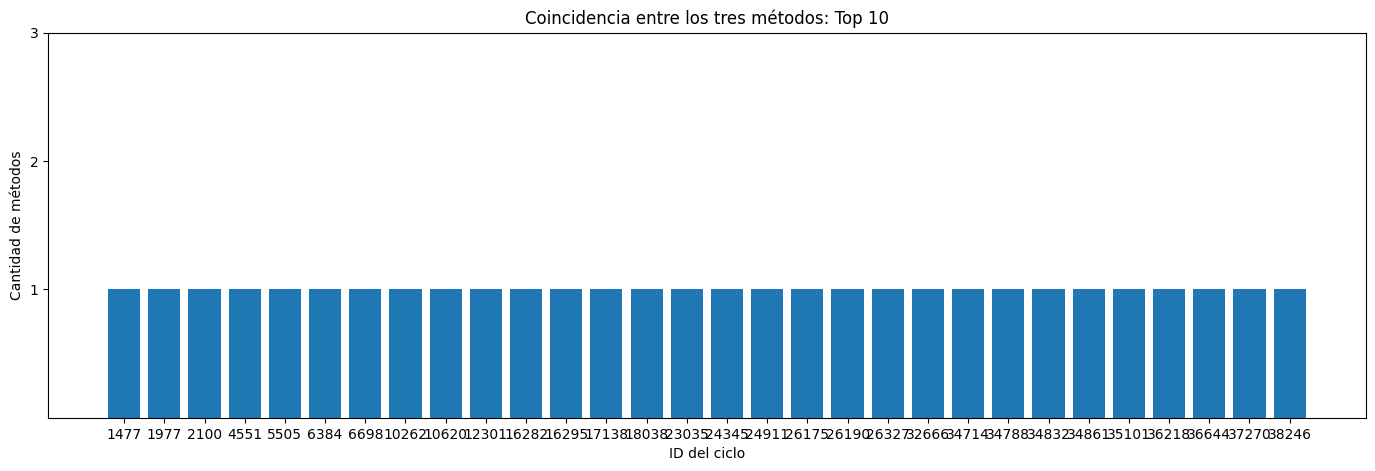

In [ ]:
#A continuación una comparación entre los 3 métodos para ver cuáles fueron los resultados en común:
#Importación de matplotlib para gráficos
!pip install matplotlib
import matplotlib.pyplot as plt

#Tomaremos el top 10:

top10_m = set(df.nlargest(10, 'mahalanobis_2')['id'])
top10_lof = set(df.nlargest(10, 'lof')['id'])
top10_if = set(df.nlargest(10, 'isolation_forest')['id'])
ids = sorted(top10_m | top10_lof | top10_if)
frecuencia = [sum(i in grupo for grupo in [top10_m, top10_lof, top10_if]) for i in ids]

plt.figure(figsize=(17, 5))
plt.bar([str(i) for i in ids], frecuencia)
plt.xlabel('ID del ciclo')
plt.ylabel('Cantidad de métodos')
plt.title('Coincidencia entre los tres métodos: Top 10')
plt.yticks([1, 2, 3])
plt.show()

No hay coincidencias entre los 3 métodos para ninguno de los outliers clasificados por Mahalanobis, LOF y Isolation Forest. A su vez se observó que el retirar campos o quitar registros con valores atípicos no altera significativamente los coeficientes de correlación con respecto a la variable Shares. De momento, no se tratarán estos valores debido a que no hay pruebas concluyentes para hacerlo.
En todo caso, si un posterior análisis descriptivo o inferencial requiere de alguna medida respecto a dichos valores, se crearon variables anteriormente para poder evaluar dichos escenarios.

## 3. ANÁLISIS EXPLORATORIO Y DESCRIPTIVO

### 3.1 Estadísticos descriptivos


In [ ]:
# Resumen estadístico de las variables numéricas.
df.describe()


,id,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mahalanobis_2,lof,isolation_forest
count,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,...,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,39643.000000000000000,2.009600000000000e+04,39643.000000000000000,39643.000000000000000
mean,19822.217087505989184,10.398784148525591,546.488913553464727,0.530546726502697,0.970209111545833,0.672796441239320,10.883686905632773,3.293469212723558,4.542971016320662,1.249905405746286,...,-0.521956893849047,-0.107502951864343,0.282360306510559,0.071427233692051,0.341851378989784,0.156067599583399,3395.317004263047693,2.569388724473524e+12,1.127308762284551,-0.078481554668921
std,11444.387085008957001,2.114051799089091,471.085403606916373,0.137111707723830,0.170012104603668,0.154035160624443,11.332160289488083,3.855042618979224,8.306261787744937,4.107902101158664,...,0.290281326488189,0.095372659424323,0.324248363750424,0.265453334800724,0.188785378635472,0.226295694394729,11627.090591971131289,2.540781686205407e+12,0.283460823576093,0.041337187144415
min,1.000000000000000,2.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,0.000000000000000,...,-1.000000000000000,-1.000000000000000,0.000000000000000,-1.000000000000000,0.000000000000000,0.000000000000000,1.000000000000000,2.607158608704908e+08,0.963163784572174,-0.144597000790784
25%,9911.500000000000000,9.000000000000000,246.000000000000000,0.470867050019500,0.999999993333000,0.625732859247000,4.000000000000000,1.000000000000000,1.000000000000000,0.000000000000000,...,-0.700000000000000,-0.125000000000000,0.000000000000000,0.000000000000000,0.166666666667000,0.000000000000000,946.000000000000000,8.466194521774707e+11,1.018615867028979,-0.107392423599718
50%,19822.000000000000000,10.000000000000000,409.000000000000000,0.539215684953000,0.999999995968000,0.690476188128000,8.000000000000000,3.000000000000000,1.000000000000000,0.000000000000000,...,-0.500000000000000,-0.100000000000000,0.150000000000000,0.000000000000000,0.500000000000000,0.000000000000000,1400.000000000000000,1.864893724918767e+12,1.066309597522434,-0.087933584577744
75%,29732.500000000000000,12.000000000000000,716.000000000000000,0.608695648393000,0.999999997647000,0.754623519196500,14.000000000000000,4.000000000000000,4.000000000000000,1.000000000000000,...,-0.300000000000000,-0.050000000000000,0.500000000000000,0.150000000000000,0.500000000000000,0.250000000000000,2800.000000000000000,3.379496632413963e+12,1.152945485207257,-0.061204355494777
max,39644.000000000000000,23.000000000000000,8474.000000000000000,0.999999966667000,0.999999999780000,0.999999985507000,304.000000000000000,116.000000000000000,128.000000000000000,91.000000000000000,...,0.000000000000000,0.000000000000000,1.000000000000000,1.000000000000000,0.500000000000000,1.000000000000000,843300.000000000000000,3.029450790072313e+13,15.769669014407665,0.160629231856206


**Interpretación del grupo:** pendiente. Aquí se deberán comentar los principales valores observados en la tabla.


### 3.2 Análisis de la variable objetivo: `shares`


In [ ]:
# Resumen estadístico específico de la variable objetivo.
df['shares'].describe()


,shares
count,39643.000000000000000
mean,3395.317004263047693
std,11627.090591971131289
min,1.000000000000000
25%,946.000000000000000
50%,1400.000000000000000
75%,2800.000000000000000
max,843300.000000000000000


**Interpretación del grupo:** pendiente. Aquí se analizará la distribución general de `shares`, su dispersión y la posible presencia de valores extremos.


### 3.3 Distribución de las variables
**Pendiente de desarrollo.**

### 3.4 Análisis de relaciones entre variables
**Pendiente de desarrollo.**

### 3.5 Matriz de correlación


In [ ]:
# Calculamos la matriz de correlación entre las variables numéricas.
df.corr()


,id,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,num_videos,...,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares,mahalanobis_2,lof,atipico_lof,isolation_forest,atipico_if
id,1.000000000000000,0.240792181158244,0.059721327557159,-0.203793472962933,-0.161480489783576,-0.188546154255213,-0.002307352158273,-0.067841961649758,0.021637702713100,-0.001392320349670,...,0.015738623956377,-0.038311686983038,-0.010987327653170,0.002772610096372,-0.009744626197417,-0.050259217760918,-0.034981703594340,-0.014295011138218,-0.101975912819212,0.080694896869789
n_tokens_title,0.240792181158244,1.000000000000000,0.018197092481156,-0.051294628837296,-0.044079173957423,-0.044517564715485,-0.053496371829699,-0.014827788410410,-0.008768504873957,0.051455451257395,...,0.077231431741632,0.000235109159077,-0.146991174025610,0.040538636533168,0.008786767905530,-0.018942230761667,-0.008832523477483,-0.020186743171459,-0.011802697947520,0.019607729054450
n_tokens_content,0.059721327557159,0.018197092481156,1.000000000000000,-0.401624834636407,0.203280739512899,-0.223119197190947,0.423089715220210,0.304616574071248,0.342449416133871,0.103721539802090,...,0.004531841423433,0.023373878171193,0.007235932839228,0.013477994057197,0.002447326036658,0.071461684547732,0.088311393152945,0.107975919248342,-0.145892032355922,-0.183043677285232
n_unique_tokens,-0.203793472962933,-0.051294628837296,-0.401624834636407,1.000000000000000,0.678052911619533,0.937679089036954,-0.113064277886280,-0.054187108622183,-0.237784135014329,0.023868204295796,...,-0.007896080521497,-0.025242496709792,-0.003982375451104,-0.019397520018019,-0.007055318598868,0.010958195324699,0.056041445143981,0.003305962961163,-0.306087437943105,-0.471661367671139
n_non_stop_words,-0.161480489783576,-0.044079173957423,0.203280739512899,0.678052911619533,1.000000000000000,0.765382113854728,0.168297569975283,0.149705905064285,0.012973124105338,0.019329052868737,...,-0.031323174749813,-0.009216790196327,0.017803106253739,-0.028599324369379,-0.019644116775083,0.035262072335805,0.060236733459537,0.023874031326138,-0.621268204553383,-0.763638506096169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
mahalanobis_2,-0.050259217760918,-0.018942230761667,0.071461684547732,0.010958195324699,0.035262072335805,-0.009607424790853,0.031211760570186,0.020456282733787,0.130112712413890,-0.084645112721380,...,-0.001153326725725,0.026754552090144,-0.025000229405485,0.009716387281602,0.013997160853290,1.000000000000000,0.081178758303547,0.082317599426614,0.062501763310802,-0.000654579681962
lof,-0.034981703594340,-0.008832523477483,0.088311393152945,0.056041445143981,0.060236733459537,0.019014995099354,0.159875357075997,0.139494081031574,0.138782571284311,0.141905373106666,...,0.097522344354216,0.010708346923719,-0.012821740007136,0.110285061523512,0.049940321141333,0.081178758303547,1.000000000000000,0.609555342135755,0.373148673307293,0.206235152324728
atipico_lof,-0.014295011138218,-0.020186743171459,0.107975919248342,0.003305962961163,0.023874031326138,-0.030286509635358,0.187990870535413,0.146817197707741,0.168798255093046,0.101620821848011,...,0.040743061586603,0.002839936009273,0.002766613160765,0.054057492750726,0.037714915790947,0.082317599426614,0.609555342135755,1.000000000000000,0.344732478747352,0.244614954677155
isolation_forest,-0.101975912819212,-0.011802697947520,-0.145892032355922,-0.306087437943105,-0.621268204553383,-0.447972889276316,0.004993930375486,-0.024142245154775,0.146763902823469,0.167266327161196,...,0.284557699619303,0.104110700154672,-0.146632713625236,0.327305749418452,0.073863373665211,0.062501763310802,0.373148673307293,0.344732478747352,1.000000000000000,0.705843861043411


**Interpretación del grupo:** pendiente. Se deberán identificar las relaciones más relevantes y posibles problemas de colinealidad.

### 3.6 Principales hallazgos del análisis exploratorio
**Pendiente de desarrollo.**


## 4. DEFINICIÓN DEL PROBLEMA PREDICTIVO



### 4.1 Pregunta de investigación, objetivo y variable objetivo

¿En qué medida las características de un artículo publicado online permiten predecir su popularidad?

OBJETIVO Predecir la popularidad de una noticia, utilizando como medida
la cantidad de veces que fue compartida.

VARIABLE OBJETIVO (y) shares

Una empresa de contenidos digitales necesita conocer, antes de publicar o promocionar un artículo, qué características están asociadas con una mayor difusión en redes sociales. Un modelo predictivo permitiría estimar la popularidad esperada de un artículo y aportar información para optimizar decisiones sobre contenido, formato y publicación.

--------------------------------------------------------------------------

### 4.2 Necesidad que busca resolver el modelo

La necesidad de negocio ya se encuentra planteada en el apartado anterior y podrá ser revisada por el grupo antes de la entrega.

### 4.3 Hipótesis iniciales

**Pendiente de acordar por el grupo.** Las hipótesis deberán formularse antes del modelado para luego contrastarlas con los resultados.


## 5. MUESTREO E INFERENCIA

### 5.1 Extracción de la muestra aleatoria de n = 750
### 5.2 Comparación muestra vs. población
### 5.3 Media de `shares`
### 5.4 Varianza de `shares`
### 5.5 Evaluación de la representatividad de la muestra

**Sección pendiente de desarrollo.**


## 6. MODELO ESTADÍSTICO: REGRESIÓN LINEAL

### 6.1 Preparación de las variables
### 6.2 Regresión lineal con la muestra de 750
### 6.3 Análisis de coeficientes y significatividad
### 6.4 Regresión lineal con la base completa
### 6.5 Análisis de coeficientes y significatividad
### 6.6 Comparación muestra vs. base completa
### 6.7 Comparación del R² y errores estándar

**Sección pendiente de desarrollo.**


## 7. MACHINE LEARNING

### 7.1 Preparación de los datos
### 7.2 División Train/Test
### 7.3 Modelo de Machine Learning N.º 1
### 7.4 Modelo de Machine Learning N.º 2
### 7.5 Evaluación: MAE, MSE, RMSE y R²
### 7.6 Comparación de los modelos
### 7.7 Análisis de importancia de variables
### 7.8 Overfitting y optimización

**Sección pendiente de desarrollo.**


## 8. COMPARACIÓN: ESTADÍSTICA vs. MACHINE LEARNING

### 8.1 Capacidad explicativa de la Regresión Lineal
### 8.2 Capacidad predictiva de Machine Learning
### 8.3 Interpretabilidad vs. precisión
### 8.4 Selección del modelo para producción

**Sección pendiente de desarrollo.**


## 9. CONCLUSIONES

### 9.1 Principales hallazgos
### 9.2 Validación de las hipótesis iniciales
### 9.3 Limitaciones del análisis
### 9.4 Variables adicionales que mejorarían el modelo
### 9.5 Conclusión final

**Sección pendiente de desarrollo.**
